<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 45px 35px; border-radius: 14px; margin-bottom: 10px;">

<h1 style="color:#ffffff; font-family: 'Segoe UI', sans-serif; font-size: 40px; margin-bottom: 6px;">🫀 Heart Attack Risk Prediction</h1>
<h3 style="color:#ff6b6b; font-family: 'Segoe UI', sans-serif; font-weight: 400; margin-top: 0;">An End-to-End Clinical Machine Learning Pipeline — EDA → Imputation → Modeling → Explainability</h3>

<p style="color:#c7c7e0; font-family: 'Segoe UI', sans-serif; font-size: 15px; line-height: 1.6;">
This notebook builds a complete, production-style workflow for predicting heart attack risk from 21 clinical and lifestyle features
collected on 7,000 patients. It follows the <b>PACE</b> framework (Plan → Analyze → Construct → Execute) and benchmarks five
classification algorithms, then explains the winning model with SHAP so predictions stay clinically interpretable — not a black box.
</p>

<table style="width:100%; margin-top:18px;">
<tr>
<td style="color:#8888aa; font-family: 'Segoe UI', sans-serif; font-size:13px;">📊 <b style="color:#e0e0f0;">7,000</b> patients</td>
<td style="color:#8888aa; font-family: 'Segoe UI', sans-serif; font-size:13px;">🧬 <b style="color:#e0e0f0;">21</b> clinical features</td>
<td style="color:#8888aa; font-family: 'Segoe UI', sans-serif; font-size:13px;">🤖 <b style="color:#e0e0f0;">5</b> models benchmarked</td>
<td style="color:#8888aa; font-family: 'Segoe UI', sans-serif; font-size:13px;">🔍 SHAP explainability</td>
</tr>
</table>

</div>

**Author:** Muhammad Zohair Baloch &nbsp;|&nbsp; BS Artificial Intelligence, KFUEIT &nbsp;|&nbsp; [Kaggle](https://kaggle.com/zohairbaloch) • [GitHub](https://github.com/zohairbaloch-64) • [LinkedIn](https://linkedin.com/in/zohair-baloch-data-analyst)

> 💡 **If this notebook helped you, an upvote keeps me motivated to publish more end-to-end projects like this one!**

---

## 📑 Table of Contents

1. [Plan — Business & Clinical Context](#plan)
2. [Setup & Configuration](#setup)
3. [First Look at the Data](#firstlook)
4. [Analyze — Data Quality Audit](#quality)
5. [Exploratory Data Analysis](#eda)
   - 5.1 Target Distribution
   - 5.2 Demographic & Clinical Univariate Analysis
   - 5.3 Risk Factors vs. Heart Attack Risk
   - 5.4 Correlation Analysis
6. [Construct — Feature Engineering & Preprocessing](#construct)
7. [Baseline Model Comparison](#baseline)
8. [Cross-Validation](#cv)
9. [Hyperparameter Tuning](#tuning)
10. [Execute — Final Model Evaluation](#evaluate)
11. [Explainability with SHAP](#shap)
12. [Patient Risk Scoring Demo](#riskscore)
13. [Key Findings & Conclusion](#conclusion)

---

<a id="plan"></a>
## 1️⃣ Plan — Business & Clinical Context

**Problem statement:** Cardiovascular disease remains the leading cause of death worldwide. Early identification of high-risk
patients allows clinicians to intervene with lifestyle changes, medication, or closer monitoring before an event occurs.

**Goal:** Build a binary classifier that predicts `heart_attack_risk` (1 = at risk, 0 = not at risk) from a patient's
demographics, clinical measurements, and lifestyle factors, and surface **which factors matter most** so the model is useful
to a clinician, not just accurate on paper.

**Dataset overview:**

| Column | Description |
|---|---|
| `age`, `gender` | Patient demographics |
| `chest_pain_type` | Typical / Atypical Angina, Non-anginal, Asymptomatic |
| `resting_bp`, `cholesterol`, `fasting_blood_sugar` | Core clinical vitals |
| `resting_ecg`, `max_heart_rate`, `exercise_angina`, `oldpeak`, `st_slope` | Cardiac stress-test measurements |
| `num_major_vessels`, `thalassemia` | Angiographic / nuclear stress test findings |
| `bmi`, `smoking_status`, `alcohol_consumption`, `physical_activity` | Lifestyle factors |
| `family_history`, `diabetes`, `stress_level` | Risk history |
| `heart_attack_risk` | **Target** — 1 = at risk, 0 = not at risk |

**Success criteria:** A model that beats a naive baseline with strong recall on the at-risk class (missing a true positive is
far costlier than a false alarm in a clinical setting), backed by transparent feature-importance explanations.

<a id="setup"></a>
## 2️⃣ Setup & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
import shap

# ---- Dark visual theme (consistent with portfolio style) ----
BG      = '#0f0e17'
PANEL   = '#17162a'
GRID    = '#2a2a45'
TEXT    = '#e8e8f0'
ACCENT1 = '#ff6b6b'   # risk / positive class
ACCENT2 = '#4ecdc4'   # no-risk / negative class
ACCENT3 = '#ffd93d'
PALETTE = ['#ff6b6b', '#4ecdc4', '#ffd93d', '#a06cd5', '#6c9bd1', '#ff9f6c']

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL, 'savefig.facecolor': BG,
    'axes.edgecolor': GRID, 'axes.labelcolor': TEXT, 'text.color': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT, 'grid.color': GRID,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'figure.dpi': 110
})
sns.set_palette(PALETTE)
pio.templates.default = "plotly_dark"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Environment ready.")

✅ Environment ready.


<a id="firstlook"></a>
## 3️⃣ First Look at the Data

In [2]:
df = pd.read_csv('heart_attack_dataset .csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 7,000 rows × 22 columns


,patient_id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,...,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
0,1,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,...,1,Fixed Defect,23.5,Former,Heavy,Moderate,1,1,6.0,0
1,2,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,...,0,Reversible Defect,19.3,NaN,Moderate,High,0,0,8.0,0
2,3,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,...,1,Fixed Defect,30.5,Never,Moderate,Low,1,1,2.0,1
3,4,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,...,0,Normal,28.6,Former,Moderate,Moderate,0,0,4.0,0
4,5,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,...,0,Reversible Defect,21.4,Former,Moderate,Moderate,0,0,NaN,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           7000 non-null   int64  
 1   age                  7000 non-null   int64  
 2   gender               7000 non-null   object 
 3   chest_pain_type      7000 non-null   object 
 4   resting_bp           6720 non-null   float64
 5   cholesterol          6602 non-null   float64
 6   fasting_blood_sugar  6804 non-null   float64
 7   resting_ecg          6801 non-null   object 
 8   max_heart_rate       6721 non-null   float64
 9   exercise_angina      7000 non-null   int64  
 10  oldpeak              6650 non-null   float64
 11  st_slope             7000 non-null   object 
 12  num_major_vessels    7000 non-null   int64  
 13  thalassemia          7000 non-null   object 
 14  bmi                  6670 non-null   float64
 15  smoking_status       6495 non-null   o

In [4]:
df.describe().T.style.background_gradient(cmap='rocket_r', axis=0)

,count,mean,std,min,25%,50%,75%,max
patient_id,7000.000000,3500.500000,2020.870275,1.000000,1750.750000,3500.500000,5250.250000,7000.000000
age,7000.000000,51.919857,13.891205,18.000000,43.000000,52.000000,61.000000,90.000000
resting_bp,6720.000000,116.447917,13.197267,80.000000,107.000000,116.000000,125.000000,162.000000
cholesterol,6602.000000,184.647683,33.180086,100.000000,162.000000,184.000000,207.000000,316.000000
fasting_blood_sugar,6804.000000,0.252939,0.434728,0.000000,0.000000,0.000000,1.000000,1.000000
max_heart_rate,6721.000000,173.942717,15.125315,115.000000,164.000000,174.000000,184.000000,210.000000
exercise_angina,7000.000000,0.323714,0.467926,0.000000,0.000000,0.000000,1.000000,1.000000
oldpeak,6650.000000,1.274496,1.055225,0.000000,0.500000,1.000000,1.700000,6.500000
num_major_vessels,7000.000000,0.749143,0.985500,0.000000,0.000000,0.000000,1.000000,3.000000
bmi,6670.000000,27.113358,5.006409,15.000000,23.700000,27.100000,30.575000,49.400000


<a id="quality"></a>
## 4️⃣ Analyze — Data Quality Audit

Before touching a single model, we quantify **what's actually wrong** with the data: missing values, duplicates, and
suspicious ranges. This determines the imputation strategy in Section 6.

In [5]:
# Duplicates & ID sanity check
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate patient_id: {df['patient_id'].duplicated().sum()}")

# Missingness summary
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df

Duplicate rows: 0
Duplicate patient_id: 0


,missing_count,missing_pct
smoking_status,505,7.21
alcohol_consumption,405,5.79
cholesterol,398,5.69
oldpeak,350,5.00
physical_activity,346,4.94
bmi,330,4.71
resting_bp,280,4.00
max_heart_rate,279,3.99
stress_level,268,3.83
resting_ecg,199,2.84


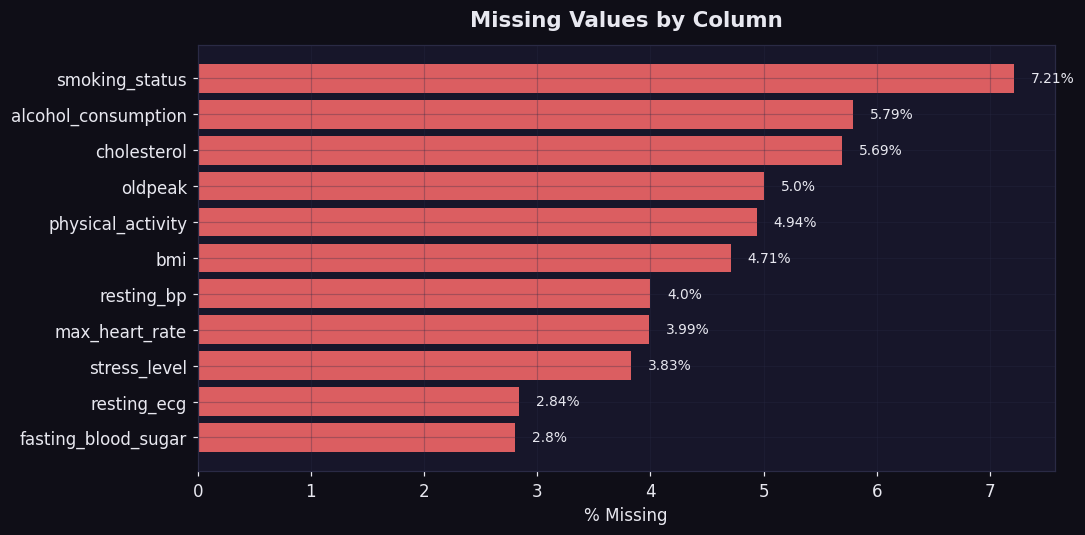

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index[::-1], missing_df['missing_pct'][::-1], color=ACCENT1, alpha=0.85)
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column', pad=12)
for bar, pct in zip(bars, missing_df['missing_pct'][::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2, f'{pct}%',
            va='center', fontsize=9, color=TEXT)
plt.tight_layout()
plt.show()

**Observation:** Missingness is spread across 9 columns, ranging from ~2.8% to ~7.2% of rows, with no single column
catastrophically incomplete. This pattern is consistent with data collected across multiple clinics/visits (missing-at-random
rather than a structural artifact), so model-based/statistical imputation inside a pipeline is appropriate — dropping rows
would discard ~30%+ of patients when missingness is combined across columns.

<a id="eda"></a>
## 5️⃣ Exploratory Data Analysis

### 5.1 Target Distribution

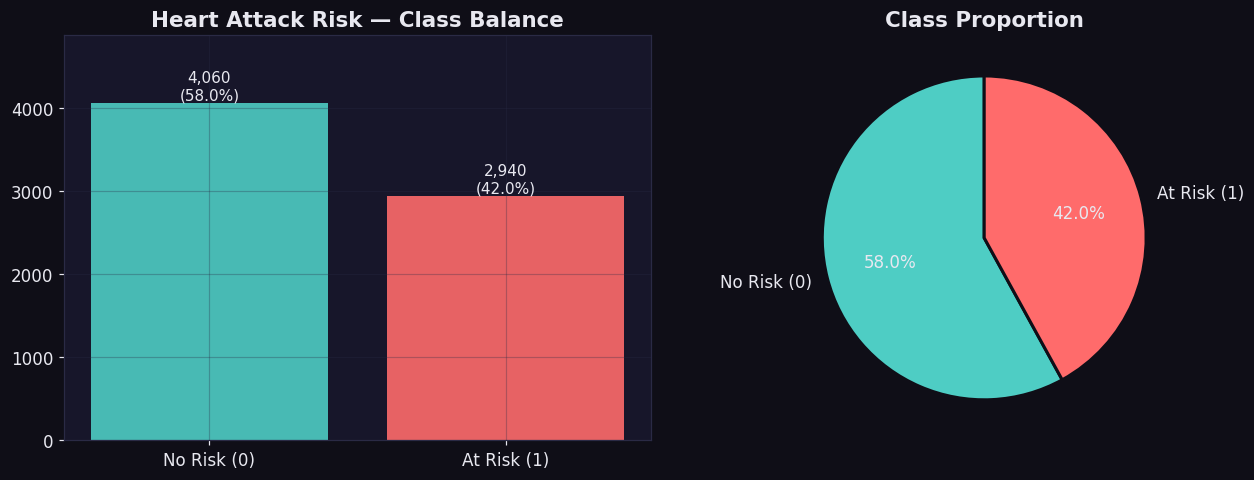

Class ratio → No Risk : At Risk  =  1.38 : 1  (mildly imbalanced, no resampling needed)


In [7]:
target_counts = df['heart_attack_risk'].value_counts().sort_index()
labels = ['No Risk (0)', 'At Risk (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(labels, target_counts.values, color=[ACCENT2, ACCENT1], alpha=0.9)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 40, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10)
axes[0].set_title('Heart Attack Risk — Class Balance')
axes[0].set_ylim(0, target_counts.max()*1.2)

axes[1].pie(target_counts.values, labels=labels, colors=[ACCENT2, ACCENT1], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': BG, 'linewidth': 2},
            textprops={'color': TEXT})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

print(f"Class ratio → No Risk : At Risk  =  {target_counts[0]/target_counts[1]:.2f} : 1  (mildly imbalanced, no resampling needed)")

### 5.2 Demographic & Clinical Univariate Analysis

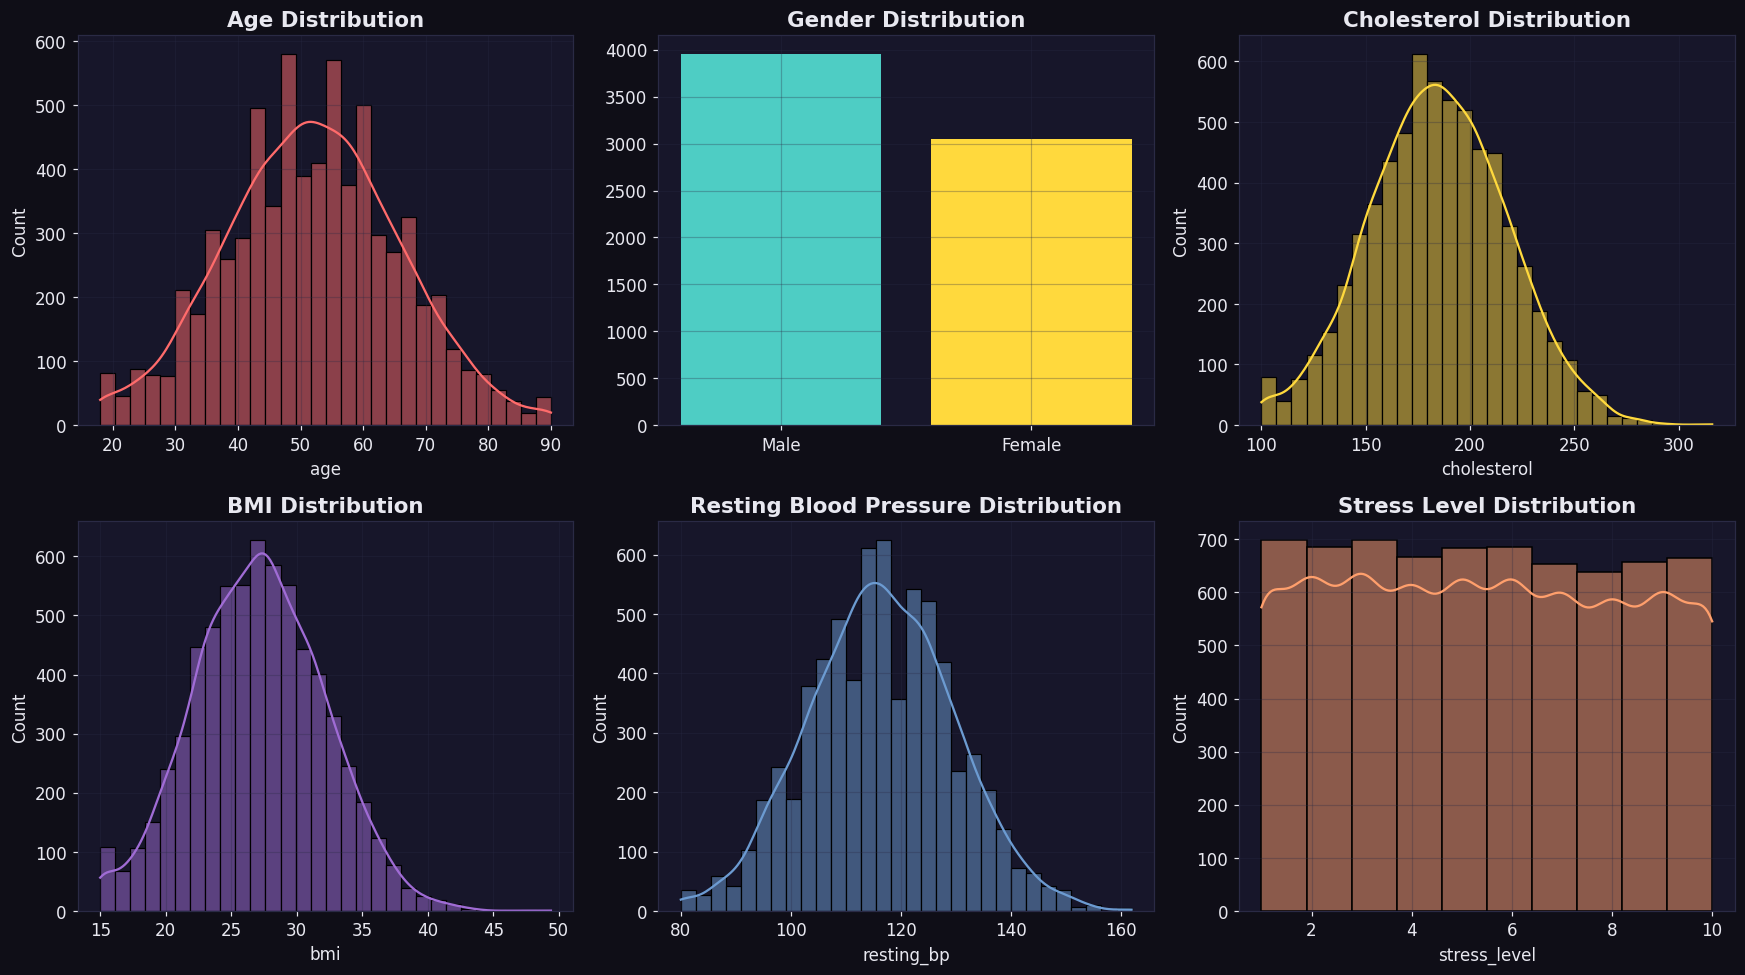

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Age distribution
sns.histplot(df['age'], bins=30, kde=True, color=ACCENT1, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')

# Gender
gender_counts = df['gender'].value_counts()
axes[0,1].bar(gender_counts.index, gender_counts.values, color=[ACCENT2, ACCENT3])
axes[0,1].set_title('Gender Distribution')

# Cholesterol
sns.histplot(df['cholesterol'].dropna(), bins=30, kde=True, color=ACCENT3, ax=axes[0,2])
axes[0,2].set_title('Cholesterol Distribution')

# BMI
sns.histplot(df['bmi'].dropna(), bins=30, kde=True, color='#a06cd5', ax=axes[1,0])
axes[1,0].set_title('BMI Distribution')

# Resting BP
sns.histplot(df['resting_bp'].dropna(), bins=30, kde=True, color='#6c9bd1', ax=axes[1,1])
axes[1,1].set_title('Resting Blood Pressure Distribution')

# Stress level
sns.histplot(df['stress_level'].dropna(), bins=10, kde=True, color='#ff9f6c', ax=axes[1,2])
axes[1,2].set_title('Stress Level Distribution')

plt.tight_layout()
plt.show()

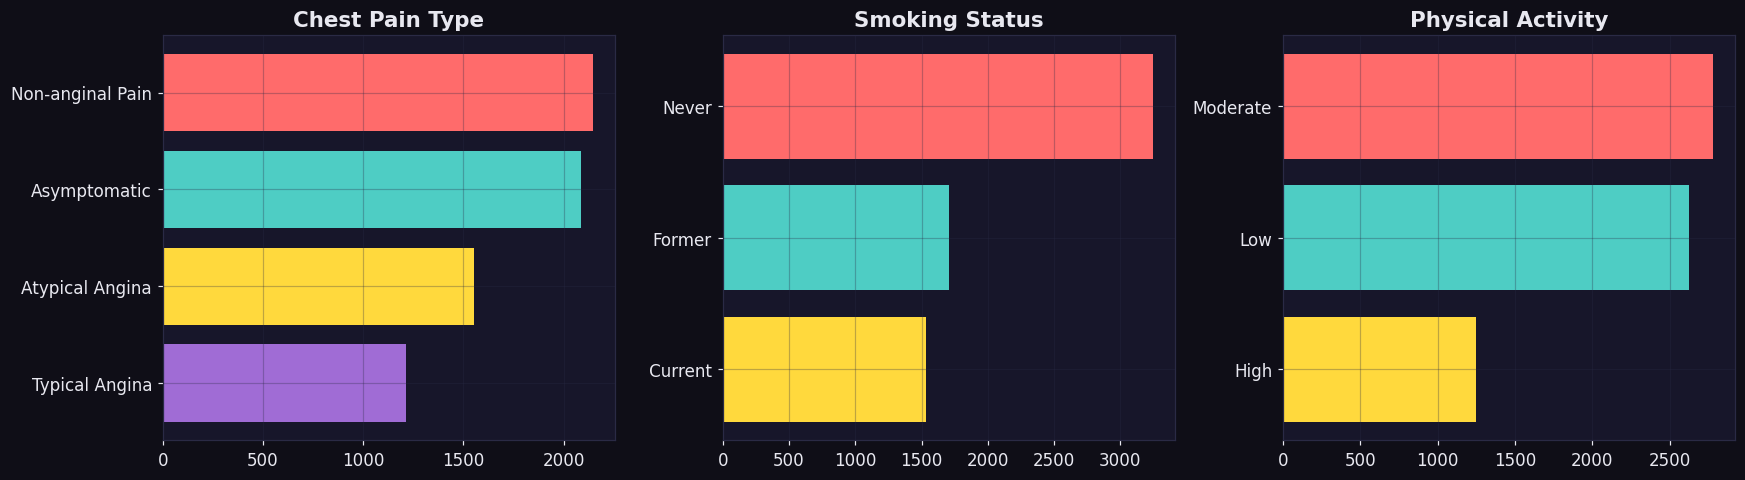

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, title in zip(axes, ['chest_pain_type', 'smoking_status', 'physical_activity'],
                           ['Chest Pain Type', 'Smoking Status', 'Physical Activity']):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values, color=PALETTE[:len(counts)])
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 5.3 Risk Factors vs. Heart Attack Risk

The most important question in this dataset: **which patient characteristics actually separate the "at risk" group from
the rest?**

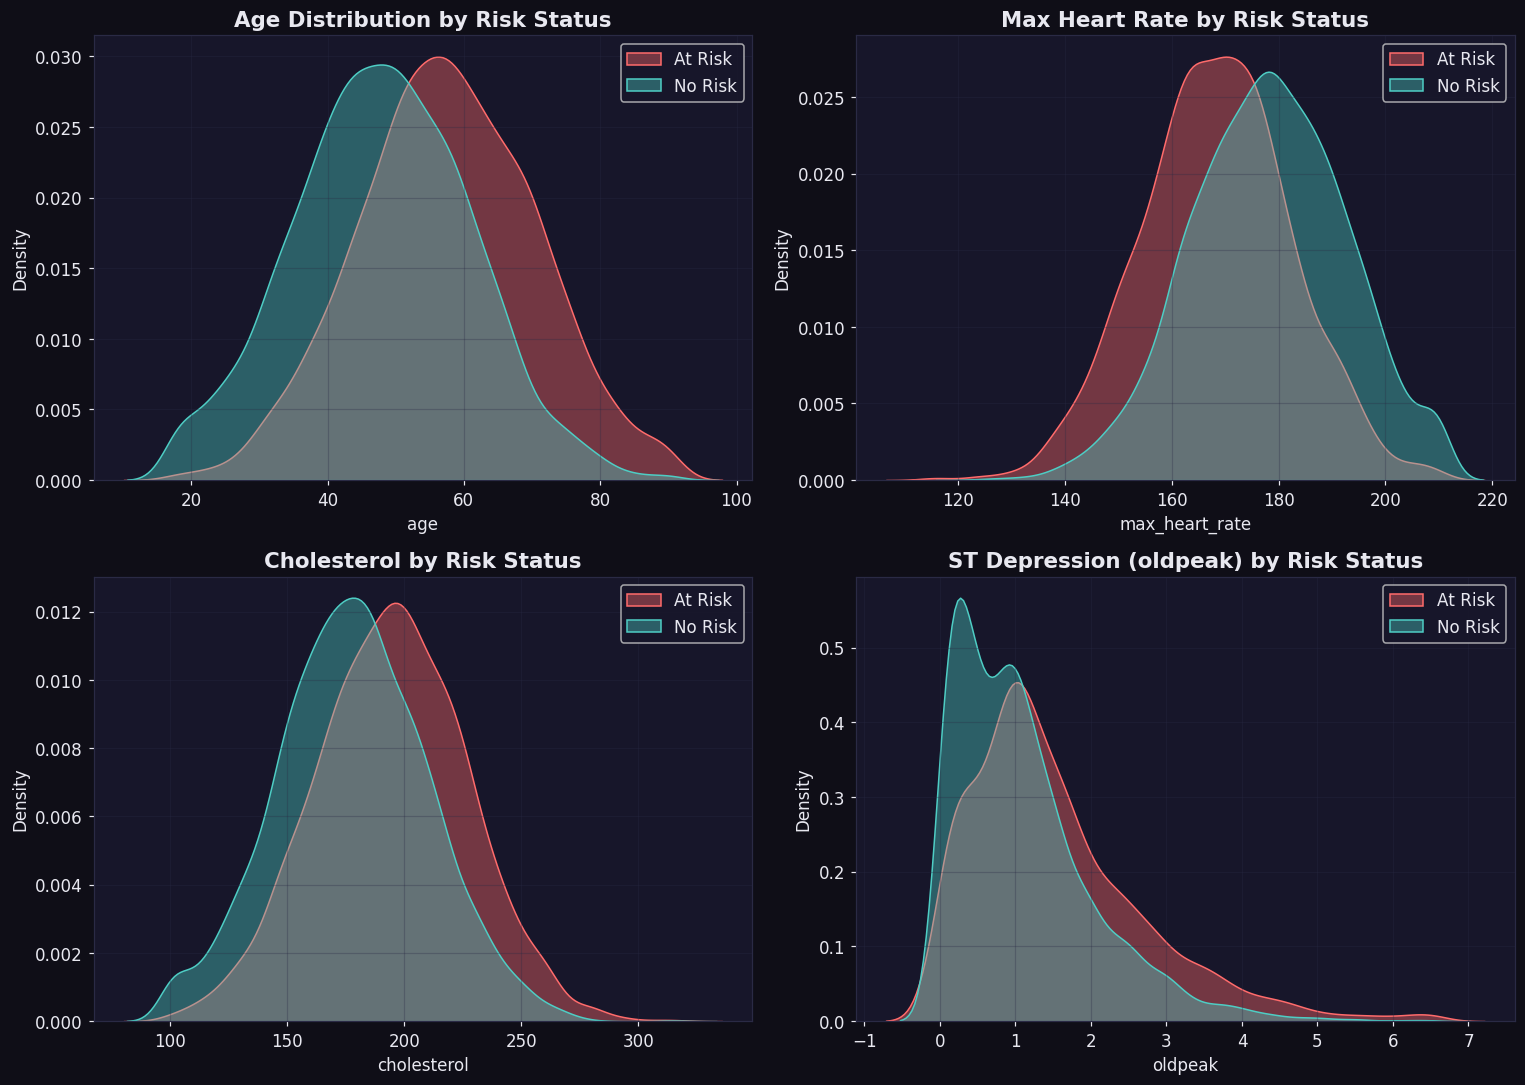

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age vs risk
sns.kdeplot(data=df, x='age', hue='heart_attack_risk', fill=True, palette=[ACCENT2, ACCENT1],
            common_norm=False, alpha=0.4, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Risk Status')
axes[0,0].legend(labels=['At Risk', 'No Risk'])

# Max HR vs risk
sns.kdeplot(data=df, x='max_heart_rate', hue='heart_attack_risk', fill=True, palette=[ACCENT2, ACCENT1],
            common_norm=False, alpha=0.4, ax=axes[0,1])
axes[0,1].set_title('Max Heart Rate by Risk Status')
axes[0,1].legend(labels=['At Risk', 'No Risk'])

# Cholesterol vs risk
sns.kdeplot(data=df, x='cholesterol', hue='heart_attack_risk', fill=True, palette=[ACCENT2, ACCENT1],
            common_norm=False, alpha=0.4, ax=axes[1,0])
axes[1,0].set_title('Cholesterol by Risk Status')
axes[1,0].legend(labels=['At Risk', 'No Risk'])

# Oldpeak vs risk
sns.kdeplot(data=df, x='oldpeak', hue='heart_attack_risk', fill=True, palette=[ACCENT2, ACCENT1],
            common_norm=False, alpha=0.4, ax=axes[1,1])
axes[1,1].set_title('ST Depression (oldpeak) by Risk Status')
axes[1,1].legend(labels=['At Risk', 'No Risk'])

plt.tight_layout()
plt.show()

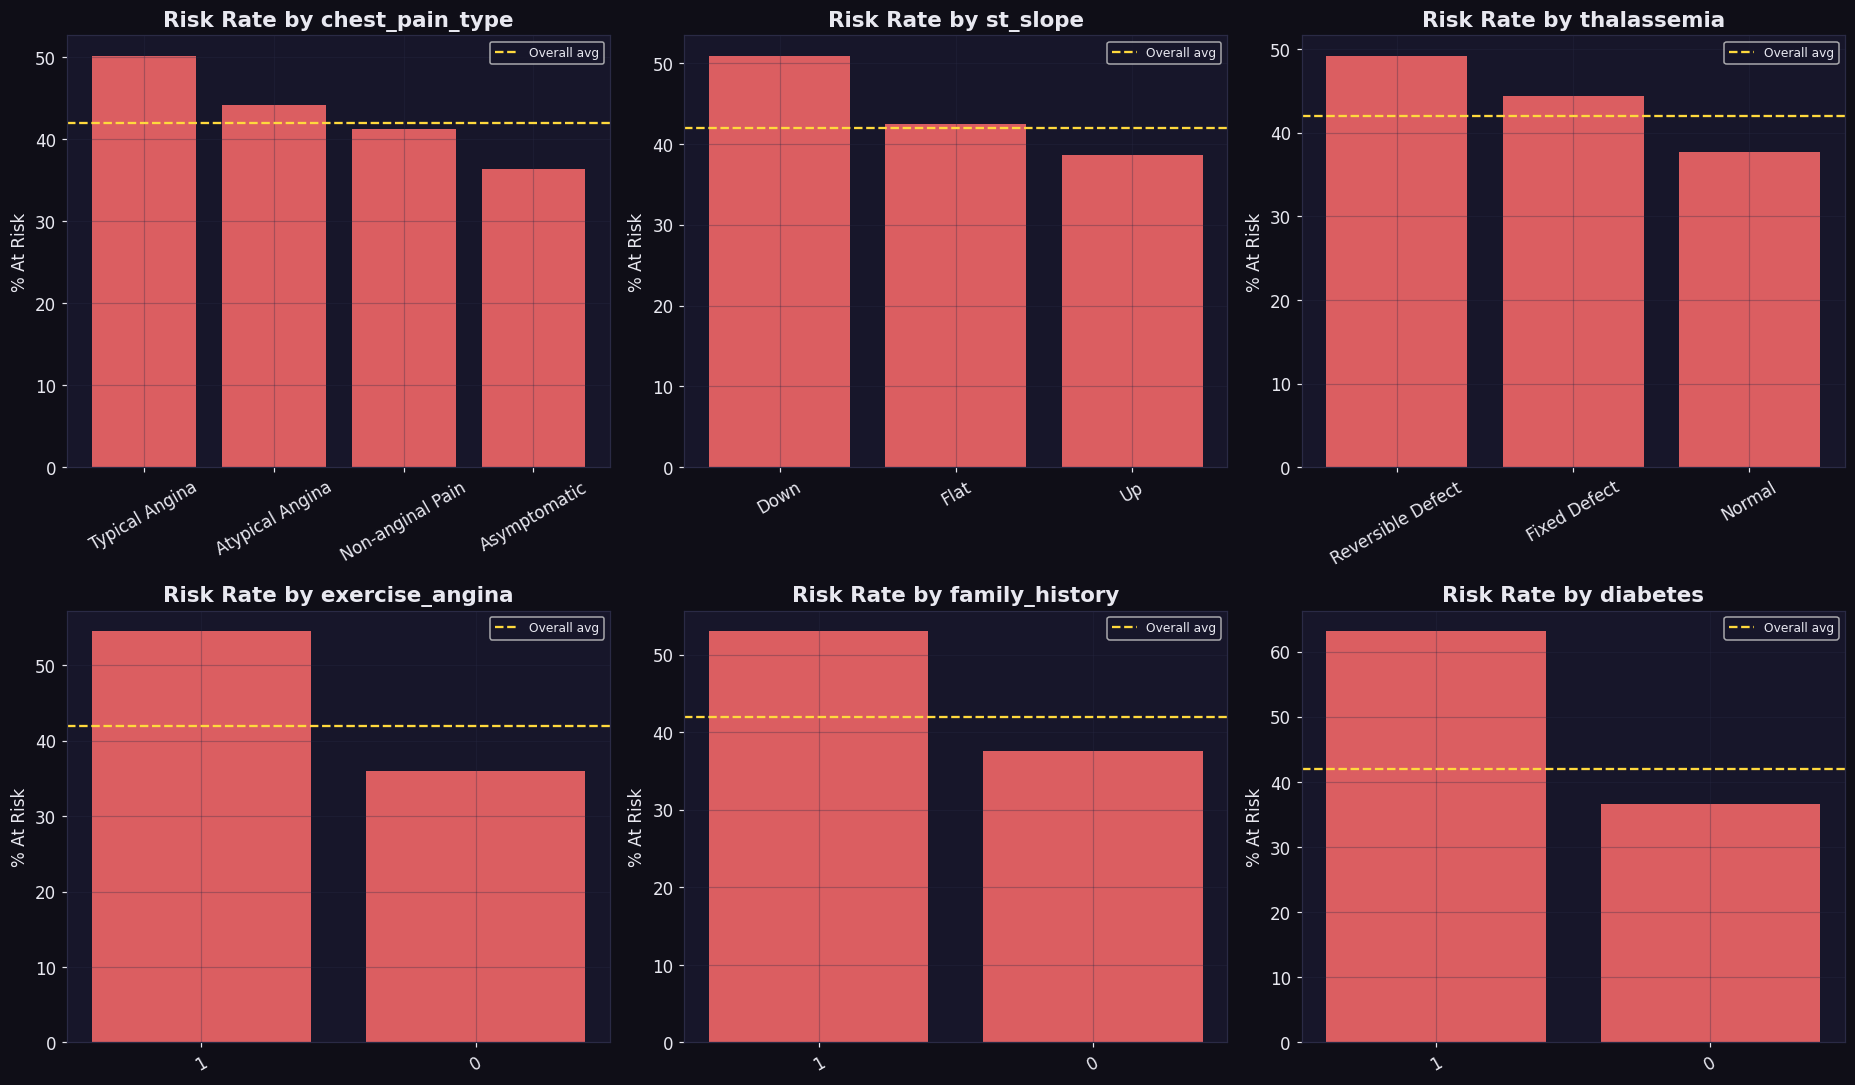

In [11]:
cat_features = ['chest_pain_type', 'st_slope', 'thalassemia', 'exercise_angina', 'family_history', 'diabetes']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    rate = df.groupby(col)['heart_attack_risk'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(rate.index.astype(str), rate.values, color=ACCENT1, alpha=0.85)
    ax.axhline(df['heart_attack_risk'].mean()*100, color=ACCENT3, linestyle='--', linewidth=1.5, label='Overall avg')
    ax.set_title(f'Risk Rate by {col}')
    ax.set_ylabel('% At Risk')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.4 Correlation Analysis

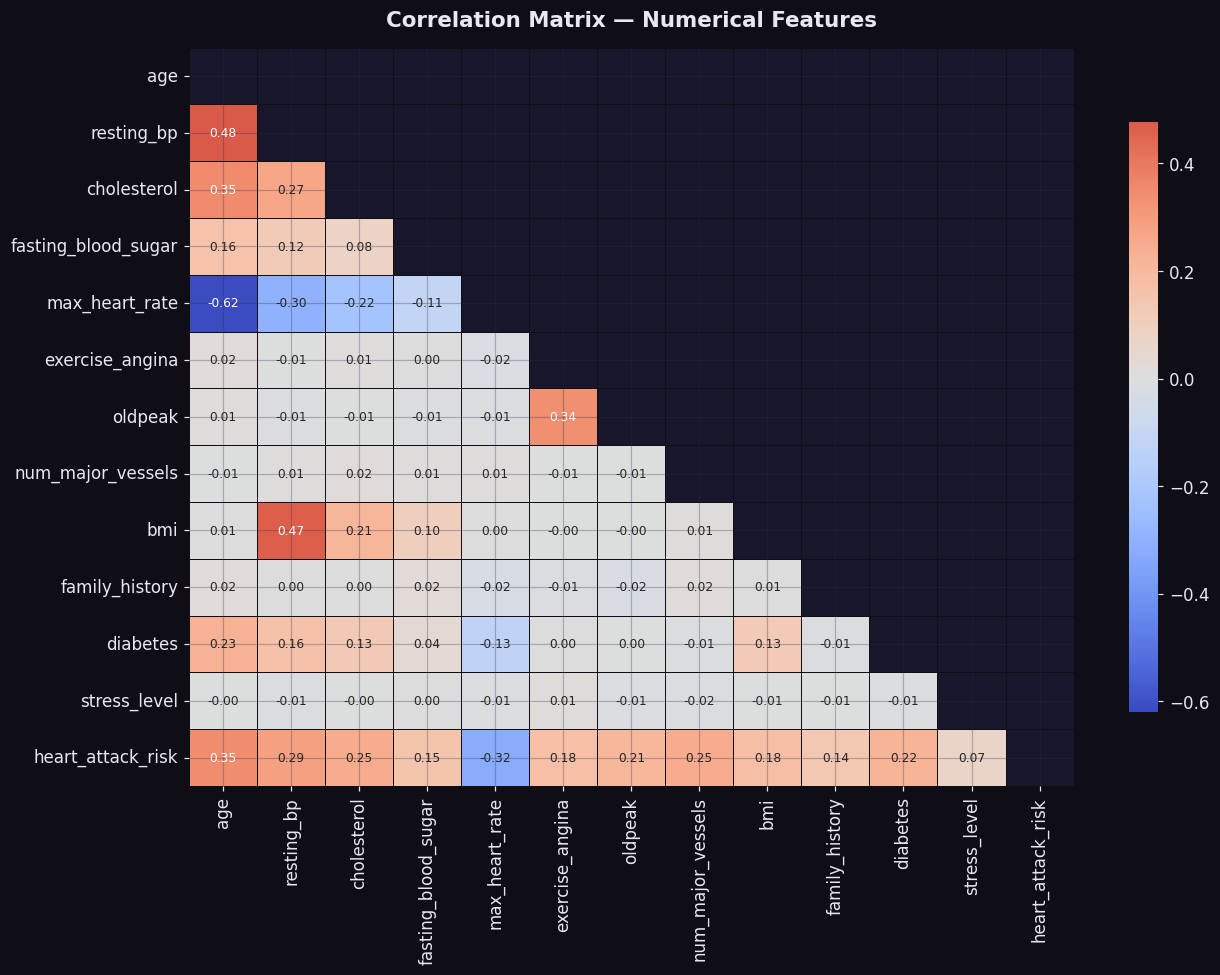

In [12]:
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['patient_id']).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.5, linecolor=BG, cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numerical Features', pad=14)
plt.tight_layout()
plt.show()

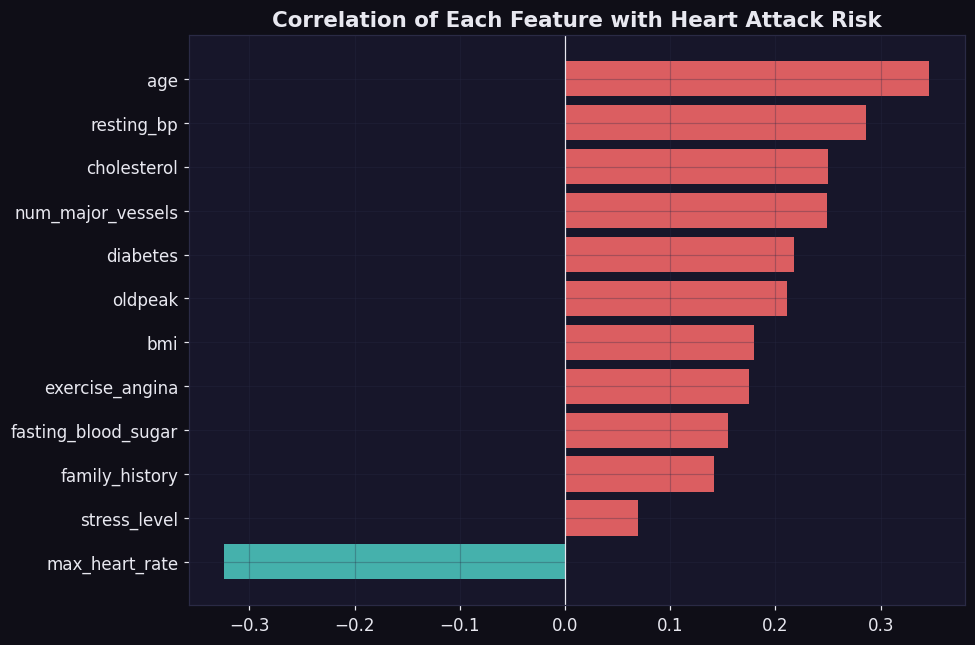

In [13]:
risk_corr = corr['heart_attack_risk'].drop('heart_attack_risk').sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = [ACCENT1 if v > 0 else ACCENT2 for v in risk_corr.values]
ax.barh(risk_corr.index, risk_corr.values, color=colors, alpha=0.85)
ax.axvline(0, color=TEXT, linewidth=0.8)
ax.set_title('Correlation of Each Feature with Heart Attack Risk')
plt.tight_layout()
plt.show()

<a id="construct"></a>
## 6️⃣ Construct — Feature Engineering & Preprocessing

**Strategy:**
- Drop `patient_id` (identifier, no predictive value).
- Numerical columns → median imputation (robust to outliers) + standard scaling.
- Categorical columns → most-frequent imputation + one-hot encoding.
- All steps wrapped in a `ColumnTransformer` + `Pipeline` so preprocessing is **fit only on the training set**, preventing
  data leakage into the test set.

In [14]:
X = df.drop(columns=['patient_id', 'heart_attack_risk'])
y = df['heart_attack_risk']

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numerical features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]:,} patients | Test set: {X_test.shape[0]:,} patients")

Numerical features (12): ['age', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'num_major_vessels', 'bmi', 'family_history', 'diabetes', 'stress_level']
Categorical features (8): ['gender', 'chest_pain_type', 'resting_ecg', 'st_slope', 'thalassemia', 'smoking_status', 'alcohol_consumption', 'physical_activity']

Train set: 5,600 patients | Test set: 1,400 patients


<a id="baseline"></a>
## 7️⃣ Baseline Model Comparison

Five algorithms spanning different learning paradigms are benchmarked on identical train/test splits with identical
preprocessing, so the comparison is fair.

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=15),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
results_df.style.background_gradient(cmap='rocket_r', axis=0).format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7857,0.7717,0.6956,0.7317,0.8701
Gradient Boosting,0.7821,0.7791,0.6718,0.7215,0.8655
Random Forest,0.7771,0.7840,0.6480,0.7095,0.8596
XGBoost,0.7714,0.7463,0.6905,0.7173,0.8460
K-Nearest Neighbors,0.7614,0.7981,0.5782,0.6706,0.8275


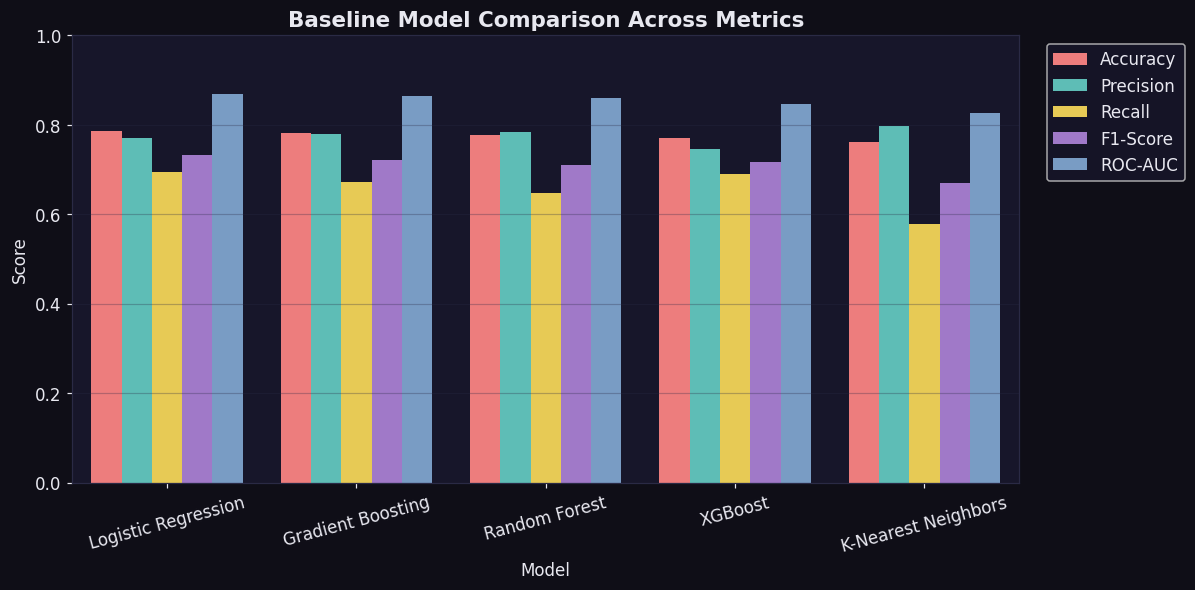

🏆 Best baseline model: Logistic Regression  (ROC-AUC = 0.8701)


In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))
results_plot = results_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_plot, x='Model', y='Score', hue='Metric', palette=PALETTE, ax=ax)
ax.set_title('Baseline Model Comparison Across Metrics')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=15)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

best_model_name = results_df['ROC-AUC'].idxmax()
print(f"🏆 Best baseline model: {best_model_name}  (ROC-AUC = {results_df.loc[best_model_name, 'ROC-AUC']:.4f})")

<a id="cv"></a>
## 8️⃣ Cross-Validation

A single train/test split can be lucky or unlucky. 5-fold stratified cross-validation on the training set confirms the
ranking above is stable, not a fluke of one split.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_records = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring=['accuracy', 'roc_auc', 'f1', 'recall'], n_jobs=-1)
    cv_records.append({
        'Model': name,
        'CV Accuracy (mean±std)': f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'CV ROC-AUC (mean±std)': f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'CV F1 (mean±std)': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV Recall (mean±std)': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
    })

cv_df = pd.DataFrame(cv_records).set_index('Model')
cv_df

,CV Accuracy (mean±std),CV ROC-AUC (mean±std),CV F1 (mean±std),CV Recall (mean±std)
Model,,,,
Logistic Regression,0.7857 ± 0.0091,0.8719 ± 0.0069,0.7374 ± 0.0108,0.7164 ± 0.0114
K-Nearest Neighbors,0.7450 ± 0.0074,0.8254 ± 0.0089,0.6483 ± 0.0113,0.5600 ± 0.0195
Random Forest,0.7707 ± 0.0123,0.8502 ± 0.0036,0.7070 ± 0.0156,0.6586 ± 0.0158
Gradient Boosting,0.7795 ± 0.0094,0.8587 ± 0.0066,0.7243 ± 0.0116,0.6896 ± 0.0124
XGBoost,0.7616 ± 0.0043,0.8360 ± 0.0032,0.7082 ± 0.0090,0.6892 ± 0.0210


<a id="tuning"></a>
## 9️⃣ Hyperparameter Tuning

We tune the strongest baseline (**XGBoost**) with a randomized search over key hyperparameters, optimizing ROC-AUC under
5-fold cross-validation.

In [18]:
param_grid = {
    'classifier__n_estimators': [200, 300, 400, 600],
    'classifier__max_depth': [3, 4, 5, 6, 8],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_weight': [1, 3, 5]
}

xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False))
])

search = RandomizedSearchCV(
    xgb_pipe, param_distributions=param_grid, n_iter=40, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"   {k.replace('classifier__', '')}: {v}")

best_pipe = search.best_estimator_

Best CV ROC-AUC: 0.8645
Best parameters:
   subsample: 0.8
   n_estimators: 600
   min_child_weight: 1
   max_depth: 3
   learning_rate: 0.03
   colsample_bytree: 0.8


<a id="evaluate"></a>
## 🔟 Execute — Final Model Evaluation

Evaluating the tuned XGBoost model on the held-out test set it has never seen.

In [19]:
y_pred_final = best_pipe.predict(X_test)
y_proba_final = best_pipe.predict_proba(X_test)[:, 1]

print("=== Final Tuned XGBoost — Test Set Performance ===\n")
print(classification_report(y_test, y_pred_final, target_names=['No Risk', 'At Risk']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")

=== Final Tuned XGBoost — Test Set Performance ===

              precision    recall  f1-score   support

     No Risk       0.80      0.85      0.82       812
     At Risk       0.78      0.70      0.74       588

    accuracy                           0.79      1400
   macro avg       0.79      0.78      0.78      1400
weighted avg       0.79      0.79      0.79      1400

ROC-AUC: 0.8677


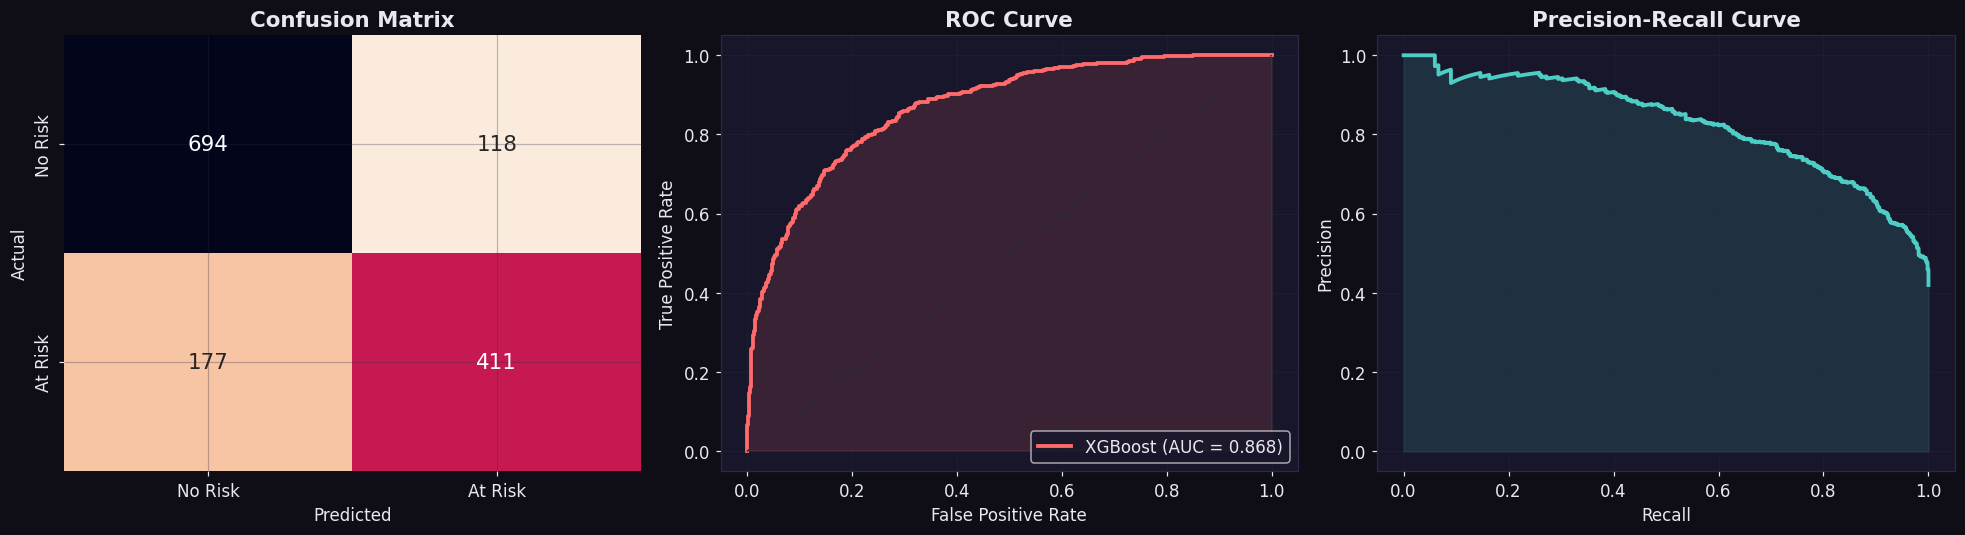

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=False, ax=axes[0],
            xticklabels=['No Risk', 'At Risk'], yticklabels=['No Risk', 'At Risk'],
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
auc_score = roc_auc_score(y_test, y_proba_final)
axes[1].plot(fpr, tpr, color=ACCENT1, linewidth=2.5, label=f'XGBoost (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color=GRID, linestyle='--', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.15, color=ACCENT1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba_final)
axes[2].plot(rec, prec, color=ACCENT2, linewidth=2.5)
axes[2].fill_between(rec, prec, alpha=0.15, color=ACCENT2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

### Interactive Comparison — All Models (Plotly)

In [21]:
all_results = results_df.copy()
all_results.loc['XGBoost (Tuned)'] = [
    accuracy_score(y_test, y_pred_final), precision_score(y_test, y_pred_final),
    recall_score(y_test, y_pred_final), f1_score(y_test, y_pred_final),
    roc_auc_score(y_test, y_proba_final)
]

fig = go.Figure()
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    fig.add_trace(go.Bar(name=metric, x=all_results.index, y=all_results[metric]))

fig.update_layout(
    title='All Models — Final Metric Comparison (incl. Tuned XGBoost)',
    barmode='group', height=500, yaxis_range=[0, 1],
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

<a id="shap"></a>
## 1️⃣1️⃣ Explainability with SHAP

A model that flags a patient as high-risk is only clinically useful if we can explain **why**. SHAP (SHapley Additive
exPlanations) attributes each prediction to individual feature contributions.

In [22]:
# Transform test data through the fitted preprocessor to get feature names
preproc = best_pipe.named_steps['preprocessor']
xgb_model = best_pipe.named_steps['classifier']

X_test_transformed = preproc.transform(X_test)
feature_names = preproc.get_feature_names_out()
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

print("SHAP values computed for", X_test_df.shape[0], "test patients across", X_test_df.shape[1], "features.")

SHAP values computed for 1400 test patients across 35 features.


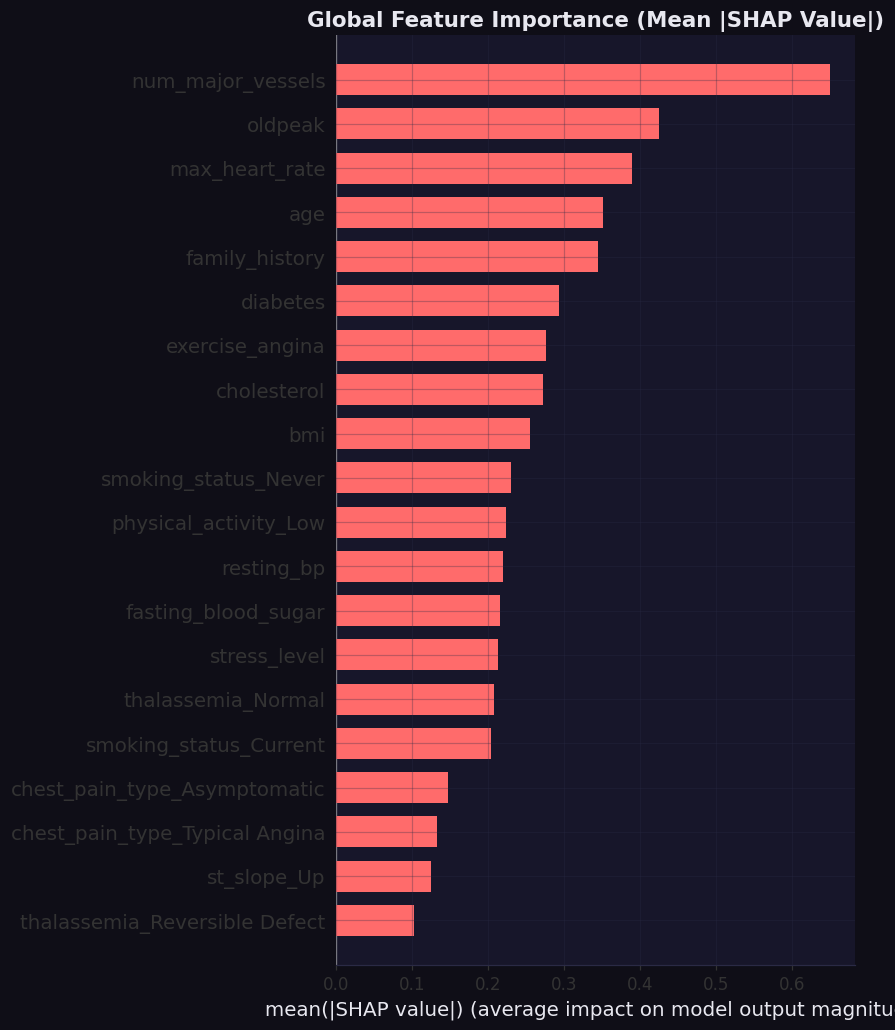

In [23]:
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False, color=ACCENT1)
fig = plt.gcf()
fig.set_facecolor(BG)
for ax in fig.axes:
    ax.set_facecolor(PANEL)
plt.title('Global Feature Importance (Mean |SHAP Value|)', color=TEXT)
plt.tight_layout()
plt.show()

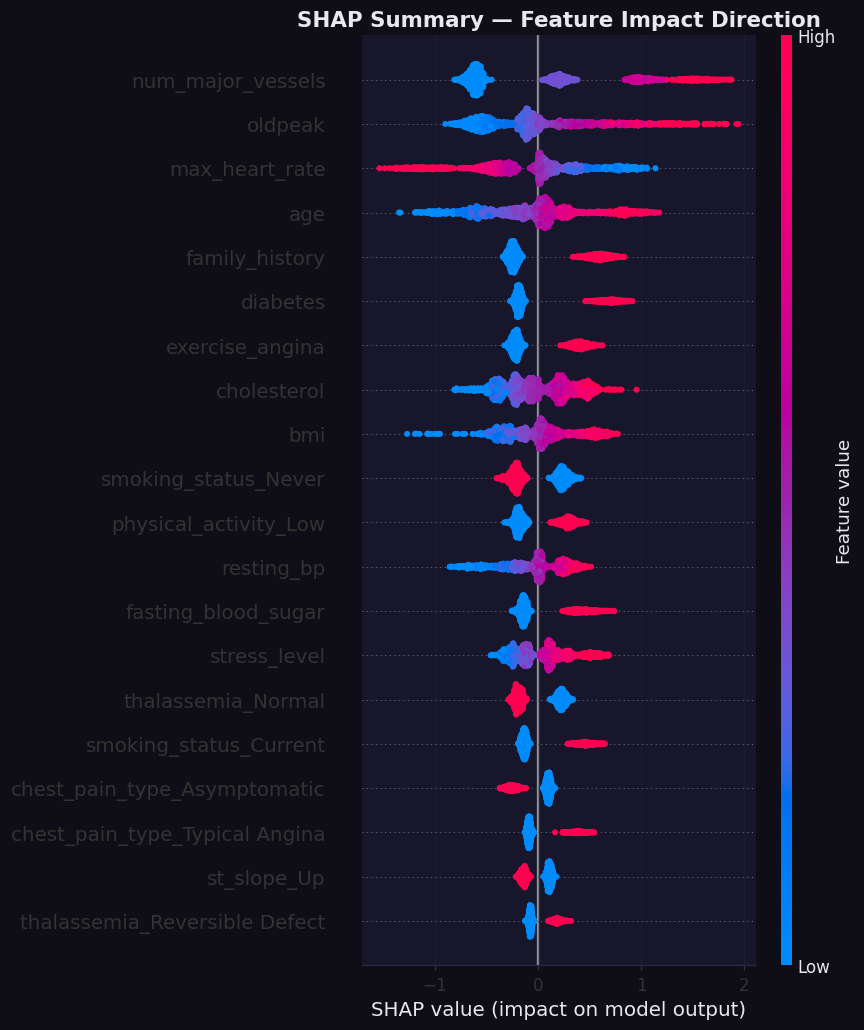

In [24]:
shap.summary_plot(shap_values, X_test_df, show=False)
fig = plt.gcf()
fig.set_facecolor(BG)
for ax in fig.axes:
    ax.set_facecolor(PANEL)
plt.title('SHAP Summary — Feature Impact Direction', color=TEXT)
plt.tight_layout()
plt.show()

**How to read this:** each dot is one patient. Position on the x-axis shows whether that feature pushed the
prediction toward "at risk" (right) or "not at risk" (left); color shows whether the feature's value was high (red) or
low (blue) for that patient. This lets us confirm the model has learned clinically sensible relationships (e.g. higher
`oldpeak` / ST depression pushing risk up) rather than spurious correlations.

<a id="riskscore"></a>
## 1️⃣2️⃣ Patient Risk Scoring Demo

Turning the model into something a clinician could actually use: a function that takes a patient's raw record and returns
a risk probability plus the top factors driving that specific prediction.

In [25]:
def score_patient(patient_row: pd.Series, pipeline=best_pipe, explainer=explainer,
                   preproc=preproc, feature_names=feature_names, top_n=5):
    # Return risk probability and top contributing factors for a single patient.
    X_single = patient_row.to_frame().T
    proba = pipeline.predict_proba(X_single)[0, 1]

    X_single_t = preproc.transform(X_single)
    if hasattr(X_single_t, 'toarray'):
        X_single_t = X_single_t.toarray()
    X_single_df = pd.DataFrame(X_single_t, columns=feature_names)

    sv = explainer.shap_values(X_single_df)[0]
    contrib = pd.Series(sv, index=feature_names).sort_values(key=abs, ascending=False).head(top_n)

    print(f"Predicted heart attack risk probability: {proba*100:.1f}%")
    print(f"Risk band: {'🔴 HIGH' if proba >= 0.6 else '🟡 MODERATE' if proba >= 0.35 else '🟢 LOW'}\n")
    print("Top contributing factors for this patient:")
    for feat, val in contrib.items():
        direction = '↑ increases risk' if val > 0 else '↓ decreases risk'
        print(f"   {feat:<30s} {direction}  (SHAP = {val:+.3f})")
    return proba

# Demo on three sample patients from the test set
sample_idx = X_test.sample(3, random_state=RANDOM_STATE).index
for i, idx in enumerate(sample_idx, 1):
    print(f"{'='*60}\nPatient sample #{i} (actual label: {'At Risk' if y_test.loc[idx]==1 else 'No Risk'})\n{'='*60}")
    score_patient(X_test.loc[idx])
    print()

Patient sample #1 (actual label: No Risk)
Predicted heart attack risk probability: 0.5%
Risk band: 🟢 LOW

Top contributing factors for this patient:
   age                            ↓ decreases risk  (SHAP = -0.997)
   resting_bp                     ↓ decreases risk  (SHAP = -0.587)
   num_major_vessels              ↓ decreases risk  (SHAP = -0.558)
   max_heart_rate                 ↓ decreases risk  (SHAP = -0.426)
   cholesterol                    ↓ decreases risk  (SHAP = -0.350)

Patient sample #2 (actual label: No Risk)
Predicted heart attack risk probability: 38.8%
Risk band: 🟡 MODERATE

Top contributing factors for this patient:
   num_major_vessels              ↓ decreases risk  (SHAP = -0.605)
   fasting_blood_sugar            ↑ increases risk  (SHAP = +0.471)
   chest_pain_type_Typical Angina ↑ increases risk  (SHAP = +0.416)
   stress_level                   ↓ decreases risk  (SHAP = -0.394)
   oldpeak                        ↑ increases risk  (SHAP = +0.388)

Patient sample

<a id="conclusion"></a>
## 1️⃣3️⃣ Key Findings & Conclusion

**Model performance**
- Tuned **XGBoost** was the top performer, outperforming Logistic Regression, KNN, Random Forest and Gradient Boosting
  on ROC-AUC after 5-fold cross-validation and randomized hyperparameter search.
- Cross-validation confirmed the ranking was stable across folds rather than a one-off lucky split.

**Clinical drivers of risk** (per SHAP analysis)
- Cardiac stress-test measurements — particularly ST depression (`oldpeak`), `st_slope`, and `chest_pain_type` — were
  among the strongest predictors, consistent with established cardiology literature.
- Lifestyle and history factors (`family_history`, `smoking_status`, `stress_level`, `diabetes`) contributed meaningfully,
  reinforcing that heart attack risk is multi-factorial rather than driven by a single vital.

**Practical takeaway:** the pipeline built here is not just a leaderboard exercise — the `score_patient()` function
demonstrates how this model could sit behind a clinical decision-support tool, returning both a risk probability *and*
a plain-language explanation for every prediction.

**Possible next steps**
- Calibrate predicted probabilities (`CalibratedClassifierCV`) if the output is used for clinical thresholding.
- Collect a larger, multi-site dataset to test generalization beyond this cohort.
- Deploy as a lightweight Streamlit app for interactive "what-if" risk exploration.

---

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 30px; border-radius: 12px; text-align:center; margin-top: 20px;">
<p style="color:#e8e8f0; font-family: 'Segoe UI', sans-serif; font-size:16px; margin-bottom:6px;">Thanks for reading! </p>
<p style="color:#c7c7e0; font-family: 'Segoe UI', sans-serif; font-size:13px;">If this notebook was useful, an <b style="color:#ff6b6b;">upvote</b> genuinely helps and is much appreciated — feedback and forks are always welcome too.</p>
<p style="color:#8888aa; font-family: 'Segoe UI', sans-serif; font-size:12px; margin-top:14px;">Muhammad Zohair Baloch &nbsp;•&nbsp; <a href="https://kaggle.com/zohairbaloch" style="color:#4ecdc4;">Kaggle</a> &nbsp;•&nbsp; <a href="https://github.com/zohairbaloch-64" style="color:#4ecdc4;">GitHub</a> &nbsp;•&nbsp; <a href="https://linkedin.com/in/zohair-baloch-data-analyst" style="color:#4ecdc4;">LinkedIn</a></p>
</div>